# Исследовательский анализ данных сервиса по бронированию билетов

**1. Описание проекта и цели**

**Цель проекта:**  
Провести исследовательский анализ данных для выявления инсайтов об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильных и стационарных устройств.

**Задачи исследования:**  
- Изучить динамику количества заказов и средней стоимости заказа в разрезе месяцев и типов устройств.  
- Выявить категории событий, которые стали наиболее популярными осенью.  
- Оценить, как изменилась средняя выручка на один заказ и на один билет.  
- Проанализировать, какие организаторы и площадки стали лидерами по числу бронирований.  
- Сравнить поведение пользователей мобильных устройств и десктопов.  
- Проверить статистические гипотезы о различиях в поведении этих двух групп.

**Бизнес-контекст:**  
С наступлением осени 2024 года на дашборде было зафиксировано увеличение количества заказов при снижении средней стоимости заказа. Продуктовая команда хочет понять причины этого явления: связано ли это с сезонностью, изменением предпочтений аудитории или другими факторами.

**2. Описание данных**

В проекте используются три датасета:

**2.1. `final_tickets_orders_df.csv` — данные о заказах билетов**  
Содержит информацию о всех заказах, совершённых с мобильных и стационарных устройств за период с 1 июня по 31 октября 2024 года.

**Поля:**  
- `order_id` — уникальный идентификатор заказа.  
- `user_id` — уникальный идентификатор пользователя.  
- `created_dt_msk` — дата создания заказа (московское время).  
- `created_ts_msk` — дата и время создания заказа (МСК).  
- `event_id` — идентификатор мероприятия.  
- `cinema_circuit` — сеть кинотеатров (если не применимо — 'нет').  
- `age_limit` — возрастное ограничение.  
- `currency_code` — валюта оплаты (rub / kzt).  
- `device_type_canonical` — тип устройства (`mobile` или `desktop`).  
- `revenue` — выручка от заказа.  
- `service_name` — билетный оператор.  
- `tickets_count` — количество купленных билетов.  
- `total` — общая сумма заказа.  
- `days_since_prev` — количество дней с предыдущей покупки пользователя (пропуск, если покупок не было).

**2.2. `final_tickets_events_df.csv` — данные о мероприятиях**  
Содержит информацию о событиях, включая географию и площадки. Фильмы исключены из датасета.

**Поля:**  
- `event_id` — уникальный идентификатор мероприятия.  
- `event_name` — название мероприятия.  
- `event_type_description` — описание типа мероприятия.  
- `event_type_main` — основной тип (театр, концерт и т.д.).  
- `organizers` — организаторы.  
- `region_name` — регион.  
- `city_name` — город.  
- `venue_id` — идентификатор площадки.  
- `venue_name` — название площадки.  
- `venue_address` — адрес площадки.

**2.3. `final_tickets_tenge_df.csv` — курсы валют**  
Содержит информацию о курсе казахстанского тенге к российскому рублю за 2024 год. Значение в рублях указано за 100 тенге.

**Поля:**  
- `nominal` — номинал (всегда 100).  
- `data` — дата курса.  
- `curs` — курс (сколько рублей за 100 тенге).  
- `cdx` — код валюты (kzt).

**3. Структура проекта**

**Шаг 1. Загрузка данных и знакомство с ними**  
- Загрузка трёх датасетов: `final_tickets_orders_df.csv`, `final_tickets_events_df.csv`, `final_tickets_tenge_df.csv`.  
- Первичный осмотр данных: просмотр первых строк, информация о типах данных.  
- Оценка объёма данных, их корректности и соответствия описанию.  
- Предположения о необходимых шагах предобработки.  
- Фиксация основных моментов в промежуточном выводе.

**Шаг 2. Предобработка данных и подготовка их к исследованию**  
- Проверка данных на пропуски (кроме столбца `days_since_prev`).  
- Изучение значений в ключевых столбцах, обработка ошибок.  
- Анализ категориальных значений: проверка на наличие значений-пропусков, нормализация при необходимости.  
- Анализ количественных значений: распределение, выбросы. Проверка столбцов `revenue` и `tickets_count` с разделением по валютам (`rub` и `kzt`). Фильтрация по 99-му процентилю для выручки.  
- Проверка явных и неявных дубликатов (особенно по бронированию без учёта идентификаторов заказа).  
- Преобразование типов данных (особенно дат и времени).  
- Объединение данных в один датафрейм.  
- Создание новых столбцов:  
  - `revenue_rub` — выручка в рублях с учётом курса тенге.  
  - `one_ticket_revenue_rub` — выручка с продажи одного билета.  
  - `month` — месяц оформления заказа.  
  - `season` — сезон ('лето', 'осень', 'зима', 'весна').  
- Проверка объёма данных после фильтрации.  
- Промежуточный вывод с описанием новых столбцов и выполненных действий.

**Шаг 3. Исследовательский анализ данных**  

**3.1. Анализ распределения заказов по сегментам и их сезонные изменения**  
- Расчёт количества заказов по месяцам, визуализация динамики. Проверка роста от июня к ноябрю 2024 года.  
- Сравнение распределения заказов для летнего и осеннего периодов по категориям:  
  - тип мероприятия (`event_type_main`),  
  - тип устройства (`device_type_canonical`),  
  - возрастной рейтинг (`age_limit`).  
  Визуализация с использованием долей для сопоставимости.  
- Анализ изменения выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью. Расчёт среднего значения и относительного изменения. Визуализация результатов.  
- Вывод о том, как меняется распределение заказов и средняя стоимость билета с наступлением осени.

**3.2. Осенняя активность пользователей**  
- Анализ динамики по дням осенью 2024 года для:  
  - общего числа заказов,  
  - количества активных пользователей (DAU),  
  - среднего числа заказов на одного пользователя,  
  - средней стоимости одного билета.  
  Построение сводной таблицы и визуализация линейных графиков.  
- Изучение недельной цикличности: сравнение активности в будни и выходные дни.  
- Промежуточный вывод о пользовательской активности и цикличности.

**3.3. Популярные события и партнёры**  
- Анализ распределения событий по регионам: расчёт уникального количества мероприятий и числа заказов на регион. Определение регионов с наибольшим разнообразием.  
- Анализ билетных партнёров: расчёт числа уникальных мероприятий, обработанных заказов и суммарной выручки. Выявление наиболее активных партнёров.  
- Исследование не только абсолютных, но и относительных показателей (доли регионов и партнёров).  
- Промежуточный вывод о лидерах среди регионов и партнёров.

**Шаг 4. Статистический анализ данных**  
- Проверка двух гипотез о большей активности пользователей мобильных устройств:  
  1. Среднее количество заказов на одного пользователя выше у мобильных пользователей.  
  2. Среднее время между заказами выше у мобильных пользователей.  
- Изучение сравниваемых данных, обоснование выбора статистического теста.  
- Формулировка нулевой и альтернативной гипотез для каждого теста.  
- Проведение тестов на данных осеннего периода.  
- Промежуточный вывод с комментариями результатов.

**Шаг 5. Общий вывод и рекомендации**  
- Краткая информация о данных.  
- Основные результаты анализа: наиболее востребованные мероприятия, изменения популярности осенью, динамика стоимости среднего чека.  
- Выводы по пользовательской активности, регионам и партнёрам.  
- Комментарии к результатам проверки гипотез.  
- Рекомендации для продуктовой команды: на что обратить внимание в первую очередь.

# Основное содержание

**Шаг 1. Загрузка данных и знакомство с ними**

In [4]:
# Импортируем все библиотеки проекта
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [5]:
# Загрузка датасетов
ft_orders = pd.read_csv('Desktop/final_tickets_orders_df.csv')
ft_events = pd.read_csv('Desktop/final_tickets_events_df.csv')
ft_tenge = pd.read_csv('Desktop/final_tickets_tenge_df.csv')

# Выводим данные для проверки
ft_orders.head(5)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [6]:
ft_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [7]:
ft_events.head(5)

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [8]:
ft_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [9]:
ft_tenge.head(5)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [10]:
ft_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [11]:
# Выводим информацию о типах данных
print(ft_orders.dtypes)
print()
print(ft_events.dtypes)
print()
print(ft_tenge.dtypes)

order_id                   int64
user_id                   object
created_dt_msk            object
created_ts_msk            object
event_id                   int64
cinema_circuit            object
age_limit                  int64
currency_code             object
device_type_canonical     object
revenue                  float64
service_name              object
tickets_count              int64
total                    float64
days_since_prev          float64
dtype: object

event_id                   int64
event_name                object
event_type_description    object
event_type_main           object
organizers                object
region_name               object
city_name                 object
city_id                    int64
venue_id                   int64
venue_name                object
venue_address             object
dtype: object

data        object
nominal      int64
curs       float64
cdx         object
dtype: object


В датафрейме `ft_orders` обнаружено 290849 строк при 14 столбцах, в `ft_events` - уже 22427 строк и 11 столбцов, а в `ft_tenge` - 357 строк и 4 столбца. Самый объёмный из них содержит почти 300 тысяч строк, что логично, так как заказов гораздо больше, чем мероприятий, а значит размеры данных коррелируют с их смыслом. Данные корректны и соответсвтуют описанию. Типы данных верные.  

**Планируемые шаги предобработки:**

1. **Преобразование типов данных:**
   - `created_dt_msk`, `created_ts_msk` (ft_orders) и `data` (ft_tenge) → `datetime`.
   

2. **Работа с пропусками:**
   - Проверить наличие скрытых пропусков (пустые строки) в категориальных столбцах.
   - Пропуски в `days_since_prev` оставить без изменений (соответствует описанию).
   

3. **Работа с выбросами:**
   - Проанализировать распределение `revenue` и `tickets_count` с разделением по валютам (`rub`/`kzt`).
   - Для `revenue` отфильтровать значения по 99-му процентилю.


4. **Проверка дубликатов:**
   - Удалить полные дубликаты строк.
   - Проверить неявные дубликаты (одинаковые бронирования без учёта `order_id`) и принять решение об их обработке.
   

5. **Объединение данных и создание новых столбцов:**
   - Объединить `ft_orders` с `ft_events` по `event_id`.
   - Объединить с `ft_tenge` по дате для конвертации валют.
   - Создать столбцы: `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`.

**Шаг 2. Предобработка данных и подготовка их к исследованию** 

На предыдущем шаге было выявлено, что пропусков ни в одном столбце (кроме `days_since_prev`) ни в одном датафрейме обнаружено не было. Значит, выгрузка данных из SQL оказалась успешной.

In [12]:
# Анализ категориальных значений
category_columns = ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 'service_name']

for col in category_columns:
    print(f'\n{col}:')
    print(f'Уникальных значений: {ft_orders[col].nunique()}')
    print(f'Значения: {ft_orders[col].unique()}')
    print(f'Пустые строки: {(ft_orders[col] == "").sum()}')


cinema_circuit:
Уникальных значений: 6
Значения: ['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']
Пустые строки: 0

age_limit:
Уникальных значений: 5
Значения: [16  0 18 12  6]
Пустые строки: 0

currency_code:
Уникальных значений: 2
Значения: ['rub' 'kzt']
Пустые строки: 0

device_type_canonical:
Уникальных значений: 2
Значения: ['mobile' 'desktop']
Пустые строки: 0

service_name:
Уникальных значений: 36
Значения: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']
Пустые строки: 0


In [13]:
# Анализ event_type_main из ft_events
print("\nevent_type_main:")
print(f"Уникальных значений: {ft_events['event_type_main'].nunique()}")
print(f"Значения: {ft_events['event_type_main'].unique()}")
print(f"Пропуски: {ft_events['event_type_main'].isna().sum()}")


event_type_main:
Уникальных значений: 7
Значения: ['театр' 'концерты' 'ёлки' 'другое' 'стендап' 'выставки' 'спорт']
Пропуски: 0


В категориальных столбцах нет данных, которые могли бы обозначать пропуски. Нормализация не требуется.

In [14]:
# Разделение по валютам
orders_rub = ft_orders[ft_orders['currency_code'] == 'rub'].copy()
orders_kzt = ft_orders[ft_orders['currency_code'] == 'kzt'].copy()

print(f"\nРубли (rub):")
print(orders_rub['revenue'].describe())
print(f"\nТенге (kzt):")
print(orders_kzt['revenue'].describe())
print()
print(ft_orders['tickets_count'].describe())


Рубли (rub):
count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64

Тенге (kzt):
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


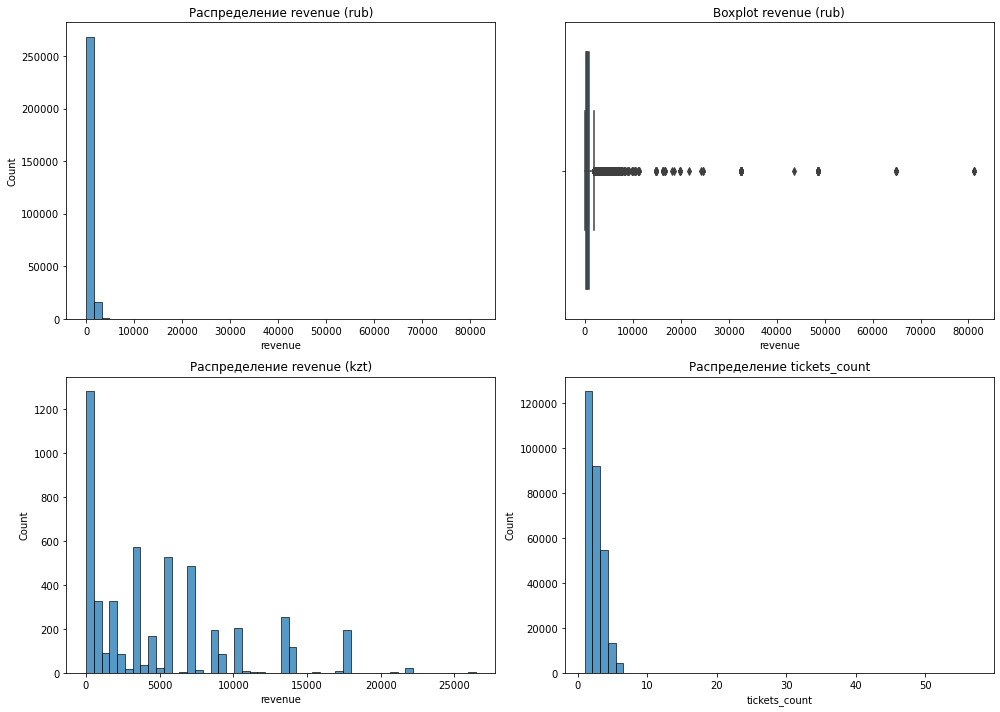

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение revenue в рублях
sns.histplot(orders_rub['revenue'], bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Распределение revenue (rub)')
axes[0, 0].set_xlabel('revenue')

# Boxplot revenue в рублях
sns.boxplot(x=orders_rub['revenue'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot revenue (rub)')

# Распределение revenue в тенге
sns.histplot(orders_kzt['revenue'], bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Распределение revenue (kzt)')
axes[1, 0].set_xlabel('revenue')

# Распределение tickets_count
sns.histplot(ft_orders['tickets_count'], bins=50, ax=axes[1, 1])
axes[1, 1].set_title('Распределение tickets_count')
axes[1, 1].set_xlabel('tickets_count')

plt.tight_layout()
plt.show()

Как видно из визуализаций, подавляющее большинство заказов приносит примерно 1000 рублей, по диаграмме размаха понимаем, что есть серьезные выбросы, требующие фильтрации по 99-му процентилю. В казахстанских тенге количество заказов не уменьшается пропорционально увеличению его стоимости, например, есть мало заказов менее 5000 тенге, а есть много заказов более 15000 тенге, тут нет такой однозначной картины, как в рублях. Количество билетов в заказе, напротив, уменьшается с увеличением числа билетов, то есть люди чаще берут меньше билетов за раз.

In [16]:
# Фильтрация по 99-му процентилю
percentile_99_rub = orders_rub['revenue'].quantile(0.99)
percentile_99_kzt = orders_kzt['revenue'].quantile(0.99)

filtered_orders_rub = orders_rub[orders_rub['revenue'] <= percentile_99_rub]
filtered_orders_kzt = orders_kzt[orders_kzt['revenue'] <= percentile_99_kzt]

# Объединение отфильтрованных данных
ft_orders_filtered = pd.concat([filtered_orders_rub, filtered_orders_kzt])

print(f"\nИсходное количество заказов: {len(ft_orders)}")
print(f"Отфильтровано по 99-му процентилю: {len(ft_orders) - len(ft_orders_filtered)}")
print(f"Осталось заказов: {len(ft_orders_filtered)}")


Исходное количество заказов: 290849
Отфильтровано по 99-му процентилю: 2887
Осталось заказов: 287962


In [17]:
count_dubli = ft_orders_filtered.duplicated(subset=['user_id', 'created_dt_msk', 'created_ts_msk',
'event_id', 'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 
'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev']).sum()

print(f'Всего неявных дубликатов без учета order_id: {count_dubli}')

Всего неявных дубликатов без учета order_id: 30


Всего неявных дубликатов (без учёта идентификатора заказа) оказалось 30 штук, то есть это дублирующиеся бронирования билетов одним и тем же пользователем в одно и то же время и, так как таковых строк оказалось мало, то их можно удалить, при этом не испортив общую статистику.

In [18]:
# Удаление неявных дубликатов (оставляем первую запись)
ft_orders_cleaned = ft_orders_filtered.drop_duplicates(
    subset=['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'cinema_circuit', 'age_limit',
            'currency_code', 'device_type_canonical', 'revenue', 'service_name', 'tickets_count',
            'total', 'days_since_prev'])

print(f"До удаления дубликатов: {len(ft_orders_filtered)} записей")
print(f"После удаления дубликатов: {len(ft_orders_cleaned)} записей")
print(f"Удалено записей: {len(ft_orders_filtered) - len(ft_orders_cleaned)}")

До удаления дубликатов: 287962 записей
После удаления дубликатов: 287932 записей
Удалено записей: 30


In [19]:
ft_orders_cleaned = ft_orders_cleaned.copy()

# Преобразование дат в datetime
ft_orders_cleaned['created_dt_msk'] = pd.to_datetime(ft_orders_cleaned['created_dt_msk'])
ft_orders_cleaned['created_ts_msk'] = pd.to_datetime(ft_orders_cleaned['created_ts_msk'])

# Преобразование event_id в строковый тип
ft_orders_cleaned['event_id'] = ft_orders_cleaned['event_id'].astype(str)

print("Типы данных после преобразования:")
print(ft_orders_cleaned.dtypes)

Типы данных после преобразования:
order_id                          int64
user_id                          object
created_dt_msk           datetime64[ns]
created_ts_msk           datetime64[ns]
event_id                         object
cinema_circuit                   object
age_limit                         int64
currency_code                    object
device_type_canonical            object
revenue                         float64
service_name                     object
tickets_count                     int64
total                           float64
days_since_prev                 float64
dtype: object


In [20]:
# Оптимизация числовых столбцов
def optimize_dtypes(df):
    df_opt = df.copy()
    
    for col in df_opt.select_dtypes(include=['int64']).columns:
        df_opt[col] = pd.to_numeric(df_opt[col], downcast='integer')
    
    for col in df_opt.select_dtypes(include=['float64']).columns:
        df_opt[col] = pd.to_numeric(df_opt[col], downcast='float')
    
    return df_opt

ft_orders_optimized = optimize_dtypes(ft_orders_cleaned)
print(ft_orders_optimized.info())
print()
print(ft_orders_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287932 entries, 0 to 290727
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               287932 non-null  int32         
 1   user_id                287932 non-null  object        
 2   created_dt_msk         287932 non-null  datetime64[ns]
 3   created_ts_msk         287932 non-null  datetime64[ns]
 4   event_id               287932 non-null  object        
 5   cinema_circuit         287932 non-null  object        
 6   age_limit              287932 non-null  int8          
 7   currency_code          287932 non-null  object        
 8   device_type_canonical  287932 non-null  object        
 9   revenue                287932 non-null  float32       
 10  service_name           287932 non-null  object        
 11  tickets_count          287932 non-null  int8          
 12  total                  287932 non-null  floa

В результате преобразования типов данных для оптимизации был снижен объем занимаемой памяти до 24,7 МБ с 33 МБ. Это произошло за счёт уменьшения размерности некоторых числовых столбцов, а именно: `order_id`, `age_limit`, `revenue`, `tickets_count`, `total` и `days_since_prev`.

In [21]:
# Преобразование даты в ft_tenge
ft_tenge['data'] = pd.to_datetime(ft_tenge['data'])
exchange_rates = dict(zip(ft_tenge['data'], ft_tenge['curs']))

# Создание столбцов
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    else:
        return row['revenue'] * (exchange_rates[row['created_dt_msk']] / 100)

ft_orders_optimized['revenue_rub'] = ft_orders_optimized.apply(convert_to_rub, axis=1)
ft_orders_optimized['one_ticket_revenue_rub'] = ft_orders_optimized['revenue_rub'] / ft_orders_optimized['tickets_count']
ft_orders_optimized['month'] = ft_orders_optimized['created_dt_msk'].dt.month

def season(month):
    if month in [6, 7, 8]: return 'лето'
    elif month in [9, 10, 11]: return 'осень'
    elif month in [12, 1, 2]: return 'зима'
    else: return 'весна'

ft_orders_optimized['season'] = ft_orders_optimized['month'].apply(season)

# Проверка
ft_orders_optimized

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,Край билетов,4,10870.990234,NaN,1521.939941,380.484985,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.450012,Мой билет,2,2067.510010,NaN,289.450012,144.725006,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.569946,За билетом!,4,13984.160156,75.0,1258.569946,314.642487,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.490000,Лови билет!,2,212.279999,NaN,8.490000,4.245000,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.410034,Билеты без проблем,3,10695.429688,83.0,1390.410034,463.470011,10,осень
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290722,6862648,ffc24188a1d58f2,2024-07-11,2024-07-11 12:39:48,538828,нет,12,kzt,mobile,4735.520020,Билеты без проблем,2,67650.359375,20.0,865.359457,432.679729,7,лето
290723,6763294,ffc24188a1d58f2,2024-09-05,2024-09-05 12:07:00,538828,нет,12,kzt,mobile,4735.520020,Билеты без проблем,2,67650.359375,56.0,872.363291,436.181646,9,осень
290724,3984021,ffc24188a1d58f2,2024-09-06,2024-09-06 19:20:03,533803,нет,16,kzt,mobile,1849.410034,Мой билет,1,30823.580078,1.0,343.072959,343.072959,9,осень
290726,8493869,ffc4133fbba20f4,2024-06-21,2024-06-21 14:04:34,533803,нет,16,kzt,mobile,3698.830078,Мой билет,2,61647.160156,NaN,687.209339,343.604670,6,лето


In [22]:
# Приведем event_id к строковому типу данных для валидного использовани merge()
ft_orders_optimized['event_id'] = ft_orders_optimized['event_id'].astype(str)
ft_events['event_id'] = ft_events['event_id'].astype(str)

# Итоговый датафрейм (заказы + события)
df = ft_orders_optimized.merge(ft_events, on='event_id', how='inner')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287694 entries, 0 to 287693
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287694 non-null  int32         
 1   user_id                 287694 non-null  object        
 2   created_dt_msk          287694 non-null  datetime64[ns]
 3   created_ts_msk          287694 non-null  datetime64[ns]
 4   event_id                287694 non-null  object        
 5   cinema_circuit          287694 non-null  object        
 6   age_limit               287694 non-null  int8          
 7   currency_code           287694 non-null  object        
 8   device_type_canonical   287694 non-null  object        
 9   revenue                 287694 non-null  float32       
 10  service_name            287694 non-null  object        
 11  tickets_count           287694 non-null  int8          
 12  total                   287694

Выводы после предобработки:

- был создан единый датайфрейм с заказами с удаленными 30 неявными дубликатами, оптимизированными типами числовых данных, отфильтрованный по 99-му процентилю по полю `revenue` для обеих валют;


- размер изначального датафрейма с заказами 290849 строк, а уже итоговый содержит 287694 строки, то есть было удалено 3155 записей (в том числе за счет присоединения датафреймов);


- пропусков обнаружено не было в исходных датасетах, что говорит о правильной SQL-выгрузке;


- для категориальных значений были рассмотрены уникальные категории и сделан вывод об отсутствии пропусков и необходимости нормализации; значений, которые могли бы обозначать пропуски, не нашлось;


- для ключевых количественных значений были построены распределения и диаграмма размаха. По одной из них видна неоднозначность и отсутствие корреляции между доходом с заказа и количеством таких заказов в тенге, скорее всего, пользователи там достаточно различны по поведению: одни предпочитают покупать мало и дешево, другие много и дорого. В рублях прослеживается тенденция по уменьшению количества заказов с увеличением их стоимости, что логично. По диаграмме размаха видны сильные выбросы, впоследствие удаленные из данных. Распределение количества билетов в заказе оказалось ожидаемым: большинство людей берут немного билетов. Чем выше число билетов, тем меньше количество таких заказов;


- были созданы некоторые столбцы: `revenue_rub` - выручка с заказа переведена из тенге в рубли с учетом актуальных курсов, `one_ticket_revenue_rub` - получена выручка с продажи одного билета, `month` - месяц оформления заказа, `season` - время года осуществления заказа.

**Шаг 3. Исследовательский анализ данных**

**3.1 Анализ распределения заказов по сегментам и их сезонные изменения**

month
6     34164
7     40404
8     44541
9     69322
10    99263
Name: order_id, dtype: int64

6     0.118751
7     0.140441
8     0.154821
9     0.240957
10    0.345030
Name: month, dtype: float64


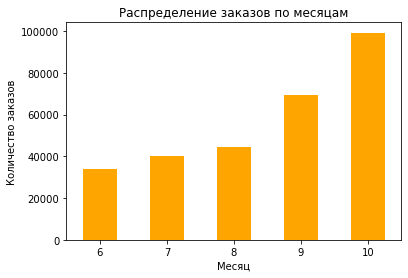

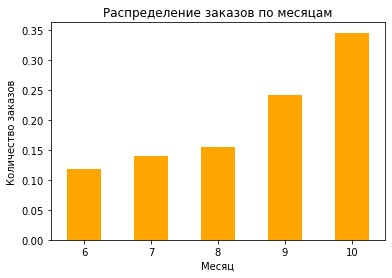

In [24]:
# Создаем распределение, группируя по месяцам
monthly_active = df.groupby('month')['order_id'].count()
print(monthly_active)
monthly_active_share = df['month'].value_counts(normalize=True).sort_values()
print(f'\n{monthly_active_share}')

monthly_active.plot(
    kind='bar',
    color='orange',
    legend=False)
plt.title('Распределение заказов по месяцам')
plt.ylabel('Количество заказов')
plt.xlabel('Месяц')
plt.xticks(rotation=0)
figsize=(10, 6)
plt.show()


monthly_active_share.plot(
    kind='bar',
    color='orange',
    legend=False)
plt.title('Распределение заказов по месяцам')
plt.ylabel('Количество заказов')
plt.xlabel('Месяц')
plt.xticks(rotation=0)
figsize=(10, 6)
plt.show()

Как видно из визуализаций, увеличение заказов фиксируется от месяца к месяцу, причем осенью скачок более резкий, чем в летний период.

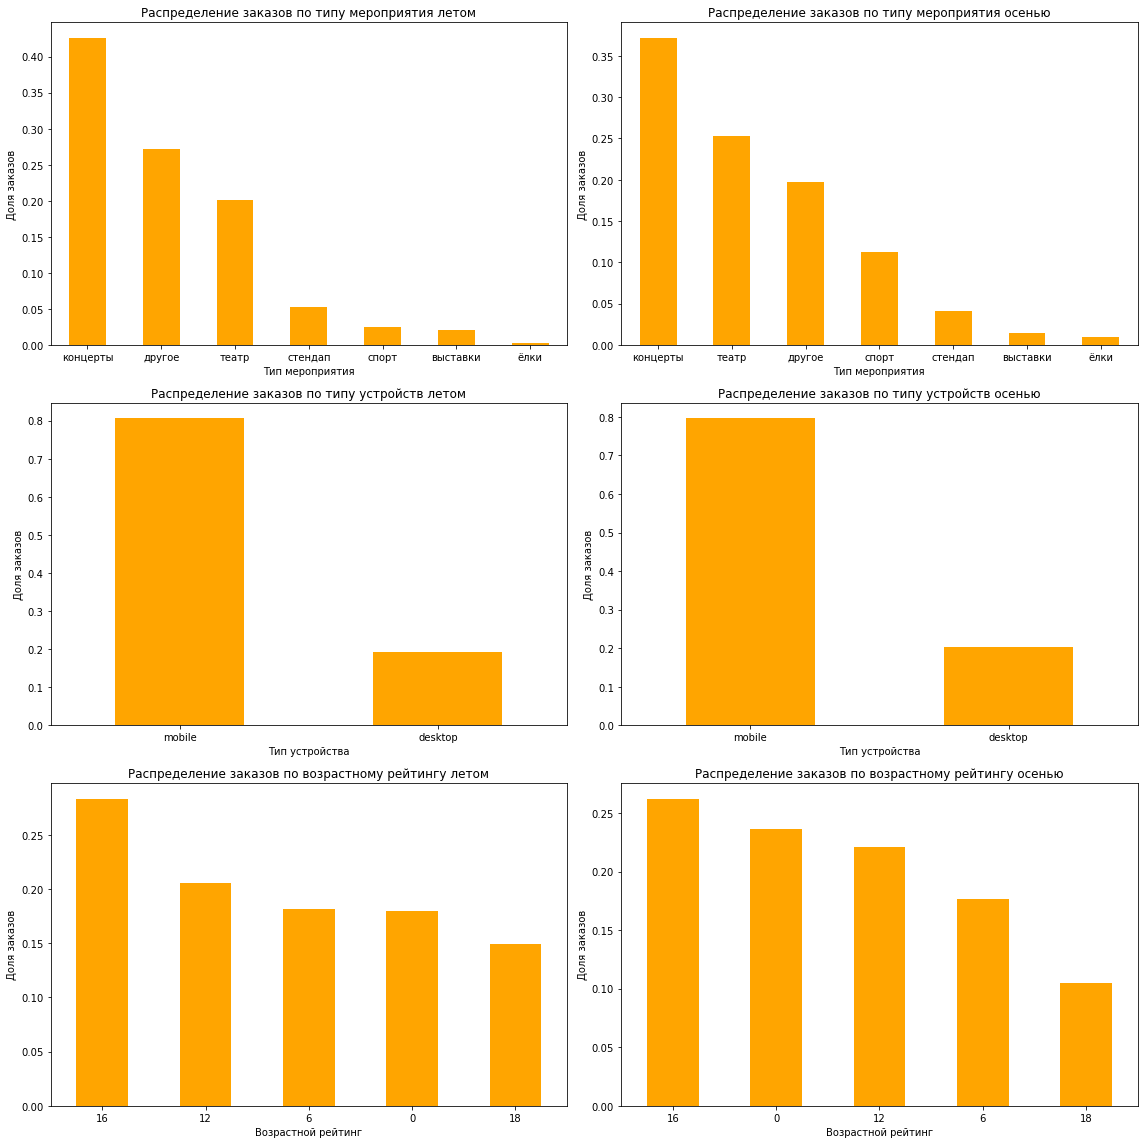

In [25]:
summer = df[df['season'] == 'лето']
autumn = df[df['season'] == 'осень']

# Тип мероприятия
plt.figure(figsize=(16, 16))

plt.subplot(3, 2, 1)
summer['event_type_main'].value_counts(normalize=True).plot(
    kind='bar',
    color='orange',
    legend=False)
plt.title('Распределение заказов по типу мероприятия летом')
plt.ylabel('Доля заказов')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=0)

plt.subplot(3, 2, 2)
autumn['event_type_main'].value_counts(normalize=True).plot(
    kind='bar',
    color='orange',
    legend=False)
plt.title('Распределение заказов по типу мероприятия осенью')
plt.ylabel('Доля заказов')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=0)

# Тип устройства
plt.subplot(3, 2, 3)
summer['device_type_canonical'].value_counts(normalize=True).plot(
    kind='bar',
    color='orange',
    legend=False)
plt.title('Распределение заказов по типу устройств летом')
plt.ylabel('Доля заказов')
plt.xlabel('Тип устройства')
plt.xticks(rotation=0)

plt.subplot(3, 2, 4)
autumn['device_type_canonical'].value_counts(normalize=True).plot(
    kind='bar',
    color='orange',
    legend=False)
plt.title('Распределение заказов по типу устройств осенью')
plt.ylabel('Доля заказов')
plt.xlabel('Тип устройства')
plt.xticks(rotation=0)

# Категория мероприятий по возрастномму рейтингу
plt.subplot(3, 2, 5)
summer['age_limit'].value_counts(normalize=True).plot(
    kind='bar',
    color='orange',
    legend=False)
plt.title('Распределение заказов по возрастному рейтингу летом')
plt.ylabel('Доля заказов')
plt.xlabel('Возрастной рейтинг')
plt.xticks(rotation=0)

plt.subplot(3, 2, 6)
autumn['age_limit'].value_counts(normalize=True).plot(
    kind='bar',
    color='orange',
    legend=False)
plt.title('Распределение заказов по возрастному рейтингу осенью')
plt.ylabel('Доля заказов')
plt.xlabel('Возрастной рейтинг')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Распределение заказов в зависимости от типа мероприятия**

И летом и осенью лидером по популярности является концерт, такое мероприятие избрали примерно 42% пользователей летом и 37% пользователей осенью. Жанры театр и другое являются также очень востребованными в оба сезона, однако в осенний период люди чаще посещают театры, нежели чем другое; летом же наоборот. Осенью также имеет неплохую популярность спорт, скорее всего, с наступлением холодов спортсмены проводят время не на улице, а за наблюдением игры любимой команды. Летом популярнее стендап.

**Распределение заказов в зависимости от типа устройства**

Оба сезона показывают идентичную картину: со смартфона бронирование билетов происходит в 80% случаев, оставшаяся часть приходится на персональные компьютеры. Следовательно, пользовательская активность в разрезе устройств не зависти от сезонности.

**Распределение заказов в зависимости от возрастного рейтинга**

Наиболее популярной оказалась категория 16+ в обоих сезонах: более 25% пользователей предпочитают события с таким ограничением. Однако осенью не сильно уступает категория 0+: дети меньше стали играть на улице и родители начали ходить с ними на мероприятия для самых маленьких. Летом события таких категорий как 12+, 6+, 0+ и 18+ распределены почти равномерно. Осенью события для детей имеют неплохую популярность.

In [26]:
# Расчёт средней выручки на один билет по типам мероприятий для лета и осени
summer_avg = summer.groupby('event_type_main')['one_ticket_revenue_rub'].mean()
autumn_avg = autumn.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# Объединение в один датафрейм в качестве визуализации
ticket_revenue = pd.DataFrame({
    'Лето': summer_avg,
    'Осень': autumn_avg
})

# Расчёт относительного изменения (в процентах)
ticket_revenue['Изменение, %'] = ((ticket_revenue['Осень'] - ticket_revenue['Лето']) / ticket_revenue['Лето'] * 100).round(1)

# Сортировка по убыванию изменения
ticket_revenue = ticket_revenue.sort_values('Изменение, %', ascending=False)

print("Средняя выручка с одного билета по типам мероприятий:")
display(ticket_revenue)

Средняя выручка с одного билета по типам мероприятий:


,Лето,Осень,"Изменение, %"
event_type_main,,,
стендап,218.518108,231.124973,5.8
выставки,86.416197,90.603609,4.8
спорт,50.761831,49.969733,-1.6
другое,77.433968,76.115333,-1.7
концерты,304.717078,268.084074,-12.0
ёлки,271.436177,229.585590,-15.4
театр,214.126334,175.969508,-17.8


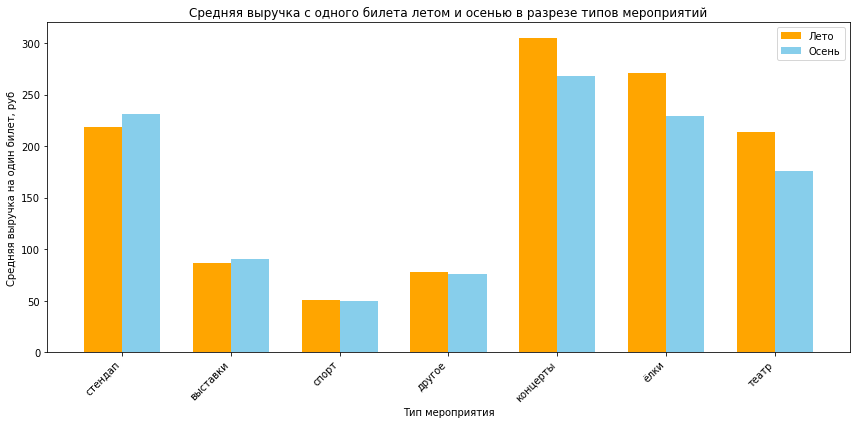

In [27]:
# Визуализация: группированные столбцы
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(ticket_revenue.index))
width = 0.35

ax.bar(x - width/2, ticket_revenue['Лето'], width, label='Лето', color='orange')
ax.bar(x + width/2, ticket_revenue['Осень'], width, label='Осень', color='skyblue')

ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Средняя выручка на один билет, руб')
ax.set_title('Средняя выручка с одного билета летом и осенью в разрезе типов мероприятий')
ax.set_xticks(x)
ax.set_xticklabels(ticket_revenue.index, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

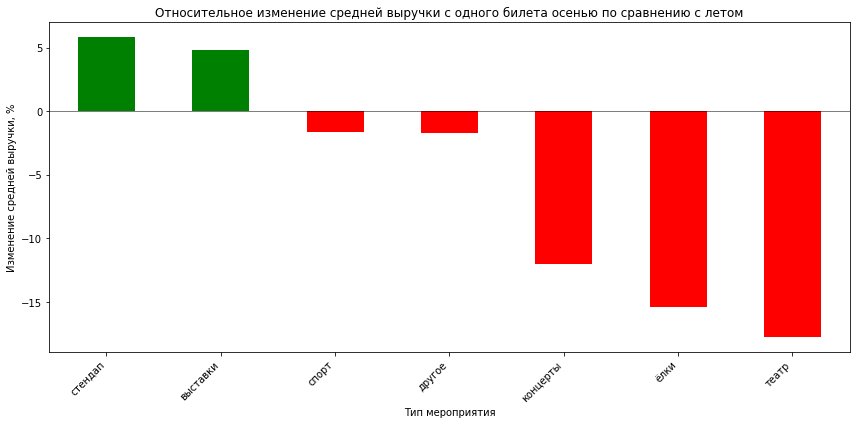

In [28]:
# Визуализация относительного изменения
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green' if x > 0 else 'red' for x in ticket_revenue['Изменение, %']]

ticket_revenue['Изменение, %'].plot(kind='bar', color=colors, ax=ax)

ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Изменение средней выручки, %')
ax.set_title('Относительное изменение средней выручки с одного билета осенью по сравнению с летом')
ax.set_xticklabels(ticket_revenue.index, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)  # Нулевая линия

plt.tight_layout()
plt.show()

1. **Динамика средней выручки:**
   - Осенью по сравнению с летом наблюдается снижение средней выручки с одного билета у большинства типов мероприятий.
   - Наибольшее падение зафиксировано у театра (-17.8%), ёлок (-15.4%) и концертов (-12.0%).
   - Рост выручки отмечен только у двух категорий: стендап (+5.8%) и выставки (+4.8%).
   - У спорта (-1.6%) и другого (-1.7%) изменение незначительное.
   

2. **Абсолютные значения:**
   - Самые дорогие билеты как летом, так и осенью - у концертов (304.7 - 268.1 руб.).
   - Самые дешёвые билеты - у спорта (50.8 - 50.0 руб.) и другого (77.4 - 76.1 руб.).
   - Театр занимает промежуточную позицию (214.1 - 176.0 руб.), но показывает самое сильное падение.


3. **Ключевой инсайт:**
   - Общее снижение средней стоимости билета на дашборде объясняется тем, что осенью подешевели билеты в самых популярных категориях - театр, концерты, ёлки.
   - При этом стендап и выставки не только не подешевели, но и немного выросли в цене, что может говорить о росте спроса на эти форматы.
   

4. **Возможные причины:**
   - Осенние скидки и специальные предложения от организаторов театров и концертных площадок.
   - Смена репертуара на более бюджетные постановки.
   - Рост количества мероприятий в сегменте "стендап" и "выставки" с более высокой ценой билета.

**3.2 Осенная активность пользователей**

In [29]:
# Создадим выборку осенних данных
autumn_data = df[df['month'] > 8]

# Подсчет количества заказов по дням
orders_by_day = autumn_data.groupby(autumn_data['created_dt_msk'].dt.date)['order_id'].count()

# Подсчет количества активных пользователей DAU
dau_by_day = autumn_data.groupby(autumn_data['created_dt_msk'].dt.date)['user_id'].nunique()

# Создаем сводную таблицу
daily_dinamic = pd.DataFrame({
    'orders': orders_by_day,
    'dau': dau_by_day
})

# Расчёт среднего числа заказов на одного пользователя
daily_dinamic['orders_per_user'] = daily_dinamic['orders'] / daily_dinamic['dau']

# Расчёт средней стоимости одного билета
avg_price_per_ticket = autumn_data.groupby(autumn_data['created_dt_msk'].dt.date)['one_ticket_revenue_rub'].mean()
daily_dinamic['avg_ticket_price'] = avg_price_per_ticket

# Сброс индекса для удобства
daily_dinamic = daily_dinamic.reset_index()
daily_dinamic.columns = ['date', 'orders', 'dau', 'orders_per_user', 'avg_ticket_price']
print('Сводная таблица дневных метрик:')
display(daily_dinamic)

Сводная таблица дневных метрик:


,date,orders,dau,orders_per_user,avg_ticket_price
0,2024-09-01,1327,564,2.352837,200.168708
1,2024-09-02,1380,574,2.404181,189.464640
2,2024-09-03,5111,778,6.569409,80.130097
3,2024-09-04,1772,685,2.586861,177.785850
4,2024-09-05,1944,739,2.630582,189.510156
...,...,...,...,...,...
56,2024-10-27,2849,1034,2.755319,186.968329
57,2024-10-28,2838,985,2.881218,170.654940
58,2024-10-29,2836,998,2.841683,177.409612
59,2024-10-30,2927,1039,2.817132,182.791483


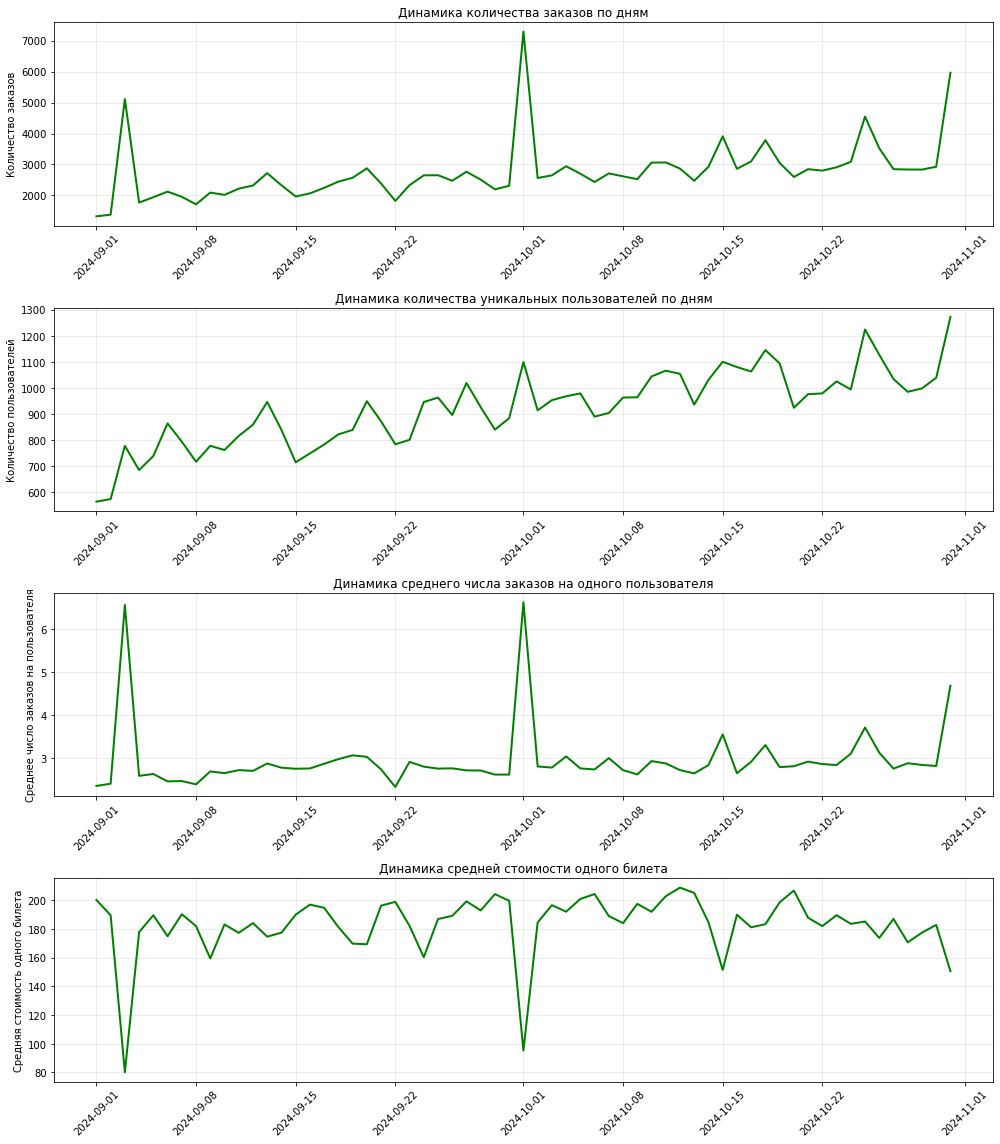

In [30]:
# Визуализация всех метрик
plt.figure(figsize=(14, 16))

# Число заказов по дням
plt.subplot(4, 1, 1)
plt.plot(daily_dinamic['date'], daily_dinamic['orders'], color='green', linewidth=2)
plt.title('Динамика количества заказов по дням', fontsize=12)
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Уникальное количество активных пользователей по дням
plt.subplot(4, 1, 2)
plt.plot(daily_dinamic['date'], daily_dinamic['dau'], color='green', linewidth=2)
plt.title('Динамика количества уникальных пользователей по дням', fontsize=12)
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Среднее число заказов на одного пользователя
plt.subplot(4, 1, 3)
plt.plot(daily_dinamic['date'], daily_dinamic['orders_per_user'], color='green', linewidth=2)
plt.title('Динамика среднего числа заказов на одного пользователя', fontsize=12)
plt.ylabel('Среднее число заказов на пользователя')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Средняя стоимость одного билета
plt.subplot(4, 1, 4)
plt.plot(daily_dinamic['date'], daily_dinamic['avg_ticket_price'], color='green', linewidth=2)
plt.title('Динамика средней стоимости одного билета', fontsize=12)
plt.ylabel('Средняя стоимость одного билета')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Вывод после анализа линейных графиков:**

- динамика количества заказов очень похожа по структуре на динамику среднего числа заказов на одного пользователя, что говорит о сильной корреляции: число заказов на юзера напрямую зависит от количества этих самых заказов. В целом дианмика \данных метрик стабильна за исключением сильнейших скачков в начале сентября и 1 октября, что, вероятно, связано с осенними акциями, мотивирующими людей покупать часто;


- рост заказов обеспечивается за счет привлечения новой аудитории (числа уникальных пользователей), что видно из второго графика, при этом новые пользователи выбирают более дешевые заказы, что влечёт за собой падение средней стомости заказа;


- средняя стоимость билета держится примерно на одном уровне, хотя к концу периода всё же немного падает. К тому же, наблюдаем резкие падения стоимости в начале сентября и 1 октября, что обратно коррелирует с динамикой среднего числа заказов на пользователя. Это логично, ведь при уменьшении стоимости билета люди покупают в среднем чаще, а значит растет и общее количество заказов в этот день.

In [31]:
autumn_data = autumn_data.copy()

# Добавляем день недели
autumn_data['day_of_week'] = autumn_data['created_dt_msk'].dt.day_name()

# Группировка по дням недели
weekly_dinamic = autumn_data.groupby('day_of_week').agg(
    orders=('order_id', 'count'),
    dau=('user_id', 'nunique')
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

print(weekly_dinamic)

             orders   dau
day_of_week              
Monday        21511  4445
Tuesday       31480  4793
Wednesday     22881  4812
Thursday      27166  4970
Friday        24826  4870
Saturday      21333  4571
Sunday        19388  4394


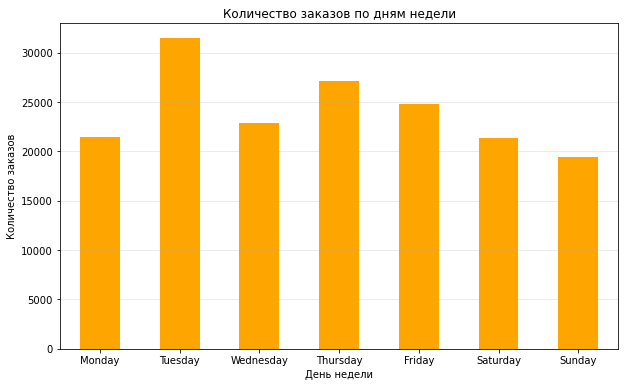

In [32]:
# График распределения заказов по дням недели
plt.figure(figsize=(10, 6))
weekly_dinamic['orders'].plot(kind='bar', color='orange')
plt.title('Количество заказов по дням недели')
plt.ylabel('Количество заказов')
plt.xlabel('День недели')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

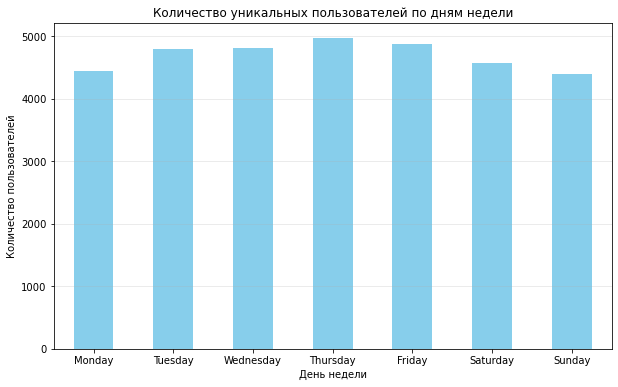

In [33]:
# График распределения количества уникальных пользователей по дням недели (DAU)
plt.figure(figsize=(10, 6))
weekly_dinamic['dau'].plot(kind='bar', color='skyblue')
plt.title('Количество уникальных пользователей по дням недели')
plt.ylabel('Количество пользователей')
plt.xlabel('День недели')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

**Вывод после анализа недельной цикличности**

- Наибольшее количество раз пользователи совершили заказы во вторник - это наиболее популярный день недели. Самую низкую активность в будние дни показали понедельник и среда - пятница и четверг находятся примерно посередине. Однако в выходные вопреки ожиданиям количество заказов меньшее среди других дней, причем самое маленькое количество оформленных заказов принадлежит воскресенью. Значит, пользователи наиболее активны в будни и именно там целесобразнее выпускать акции, которые увеличат выручку и поднимут число бронирований еще выше.


- Что касается метрики DAU (количество уникальных активных пользователей ежедневно), то тут различия по дням едва ли заметны. Число активных юзеров около 4500 человек в начале недели, ровно 5000 в середине и примерно 4400 в конце. Тем не менее, хоть и разница небольшая, стоит обратить внимание на выходные - там по-прежнему одни из самых низких показателей по активности.

**3.3 Популярные события и партнёры**

In [34]:
# Сводная таблица для регионов
grouped_regions = df.groupby('region_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count')
).sort_values('events', ascending=False)
grouped_regions

,events,orders
region_name,,
Каменевский регион,5935,89665
Североярская область,3800,43738
Широковская область,1232,16169
Светополянский округ,1075,7502
Речиновская область,702,6267
...,...,...
Теплоозёрский округ,2,7
Сосноводолинская область,2,10
Лесноярский край,2,19


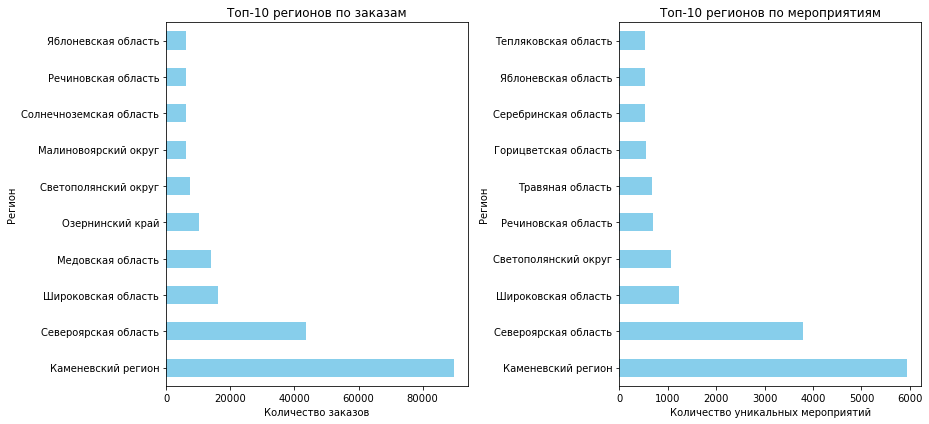

In [35]:
# Визуализируем топ-10 регионов по количеству заказов и количеству уникальных мероприятий
plt.figure(figsize=(13, 6))

plt.subplot(1, 2, 1)
grouped_regions['orders'].sort_values(ascending=False).head(10).plot(kind='barh', color='skyblue')
plt.title('Топ-10 регионов по заказам')
plt.xlabel('Количество заказов')
plt.ylabel('Регион')

plt.subplot(1, 2, 2)
grouped_regions['events'].sort_values(ascending=False).head(10).plot(kind='barh', color='skyblue')
plt.title('Топ-10 регионов по мероприятиям')
plt.xlabel('Количество уникальных мероприятий')
plt.ylabel('Регион')

plt.tight_layout()
plt.show()

In [36]:
# Расчёт долей
grouped_regions['events_share'] = (grouped_regions['events'] / grouped_regions['events'].sum() * 100).round(1)
grouped_regions['orders_share'] = (grouped_regions['orders'] / grouped_regions['orders'].sum() * 100).round(1)
grouped_regions

,events,orders,events_share,orders_share
region_name,,,,
Каменевский регион,5935,89665,26.5,31.2
Североярская область,3800,43738,17.0,15.2
Широковская область,1232,16169,5.5,5.6
Светополянский округ,1075,7502,4.8,2.6
Речиновская область,702,6267,3.1,2.2
...,...,...,...,...
Теплоозёрский округ,2,7,0.0,0.0
Сосноводолинская область,2,10,0.0,0.0
Лесноярский край,2,19,0.0,0.0


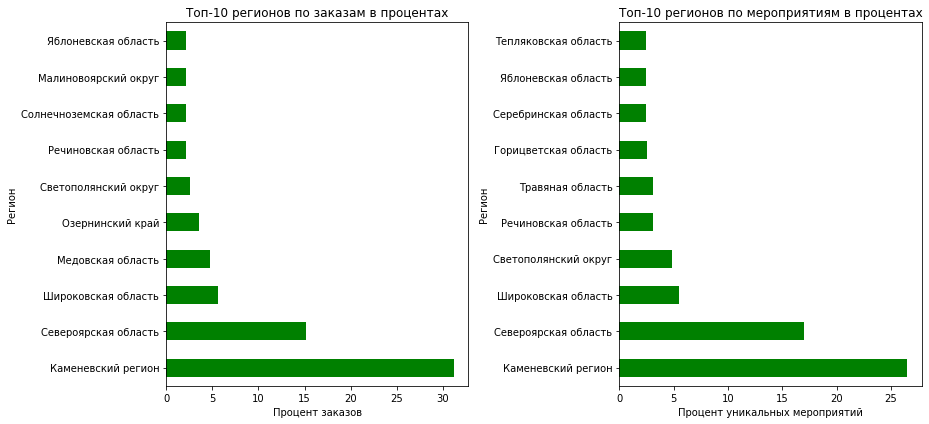

In [37]:
# Визуализируем топ-10 регионов по количеству заказов и количеству уникальных мероприятий в долях
plt.figure(figsize=(13, 6))

plt.subplot(1, 2, 1)
grouped_regions['orders_share'].sort_values(ascending=False).head(10).plot(kind='barh', color='green')
plt.title('Топ-10 регионов по заказам в процентах')
plt.xlabel('Процент заказов')
plt.ylabel('Регион')

plt.subplot(1, 2, 2)
grouped_regions['events_share'].sort_values(ascending=False).head(10).plot(kind='barh', color='green')
plt.title('Топ-10 регионов по мероприятиям в процентах')
plt.xlabel('Процент уникальных мероприятий')
plt.ylabel('Регион')

plt.tight_layout()
plt.show()

Графики в процентах повторяют графики в абсолютных значениях структурно. Мы видим, что лидером как по разнообразию мероприятий, так и по количеству заказов является Каменевский регион - 89665 заказов, что составляет 31,2% от всего числа заказов и 5935 уникальных мероприятий - 26,5% от общего числа уникальных мероприятий в каждом регионе. 

Второе место занимает Североярская область - 43738 заказов (15,2%) и 3800 уникальных мероприятий (17%), что меньше около 2 раз, чем в Каменевском регионе. Остальные регионы сильно уступают первым двум, что говорит о меньшей популярности мероприятий в них (быть может из-за численности населения и благосостояния граждан).

In [38]:
# Сводная таблица для билетных партнеров
grouped_service_name = df.groupby('service_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('revenue_rub', 'sum')
).sort_values('events', ascending=False)
grouped_service_name

,events,orders,revenue
service_name,,,
Лови билет!,4867,40800,1.667033e+07
Билеты без проблем,4247,62832,2.425535e+07
Билеты в руки,3530,40281,1.319433e+07
Облачко,2335,26402,1.858861e+07
Лучшие билеты,1762,17740,2.721491e+06
Мой билет,1300,34440,2.204236e+07
Тебе билет!,1062,5177,2.928883e+06
Прачечная,1026,10222,4.746811e+06
Весь в билетах,855,16410,1.649467e+07


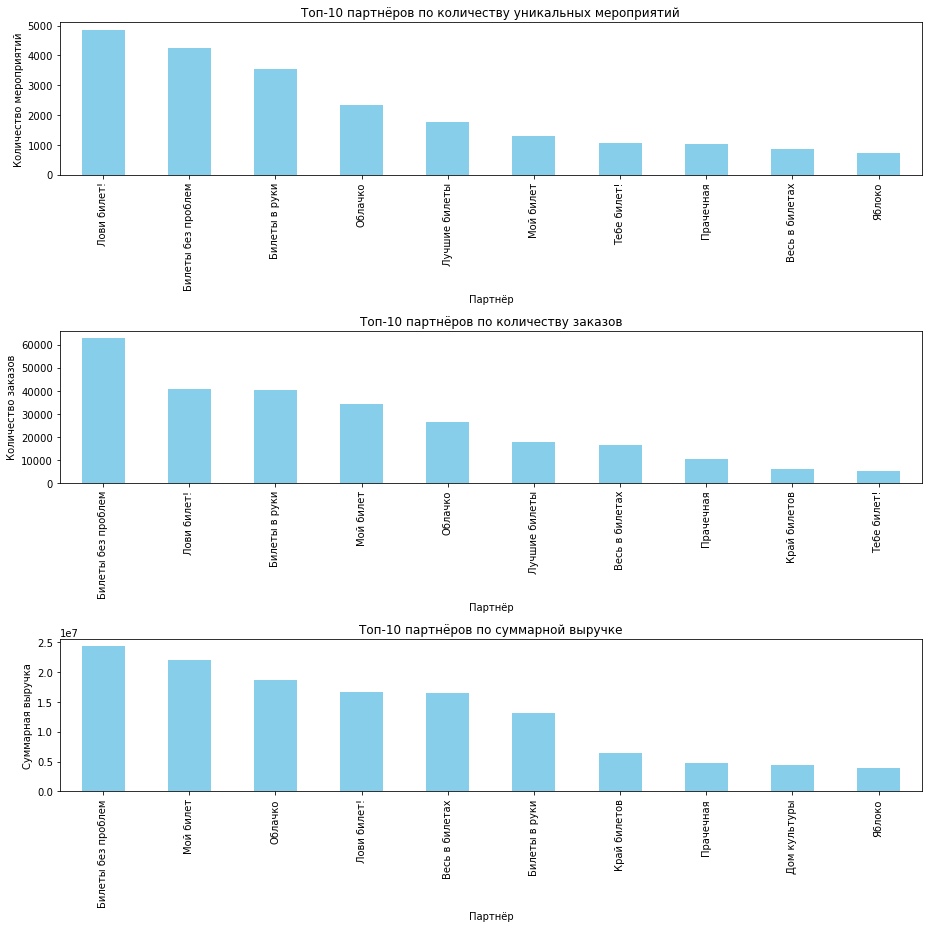

In [39]:
# Визуализируем топ-10 (топ-5) партнёров по количеству заказов, количеству уникальных мероприятий и суммарно
plt.figure(figsize=(13, 13))

plt.subplot(3, 1, 1)
grouped_service_name['events'].sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title('Топ-10 партнёров по количеству уникальных мероприятий')
plt.ylabel('Количество мероприятий')
plt.xlabel('Партнёр')

plt.subplot(3, 1, 2)
grouped_service_name['orders'].sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title('Топ-10 партнёров по количеству заказов')
plt.ylabel('Количество заказов')
plt.xlabel('Партнёр')

plt.subplot(3, 1, 3)
grouped_service_name['revenue'].sort_values(ascending=False).head(10).plot(kind='bar', color='skyblue')
plt.title('Топ-10 партнёров по суммарной выручке')
plt.ylabel('Суммарная выручка')
plt.xlabel('Партнёр')

plt.tight_layout()
plt.show()

In [40]:
# Расчёт долей
grouped_service_name['events_share'] = (grouped_service_name['events'] / grouped_service_name['events'].sum() * 100).round(2)
grouped_service_name['orders_share'] = (grouped_service_name['orders'] / grouped_service_name['orders'].sum() * 100).round(2)
grouped_service_name['revenue_share'] = (grouped_service_name['revenue'] / grouped_service_name['revenue'].sum() * 100).round(2)
grouped_service_name

,events,orders,revenue,events_share,orders_share,revenue_share
service_name,,,,,,
Лови билет!,4867,40800,1.667033e+07,19.96,14.18,11.18
Билеты без проблем,4247,62832,2.425535e+07,17.42,21.84,16.27
Билеты в руки,3530,40281,1.319433e+07,14.48,14.00,8.85
Облачко,2335,26402,1.858861e+07,9.58,9.18,12.47
Лучшие билеты,1762,17740,2.721491e+06,7.23,6.17,1.83
Мой билет,1300,34440,2.204236e+07,5.33,11.97,14.78
Тебе билет!,1062,5177,2.928883e+06,4.36,1.80,1.96
Прачечная,1026,10222,4.746811e+06,4.21,3.55,3.18
Весь в билетах,855,16410,1.649467e+07,3.51,5.70,11.06


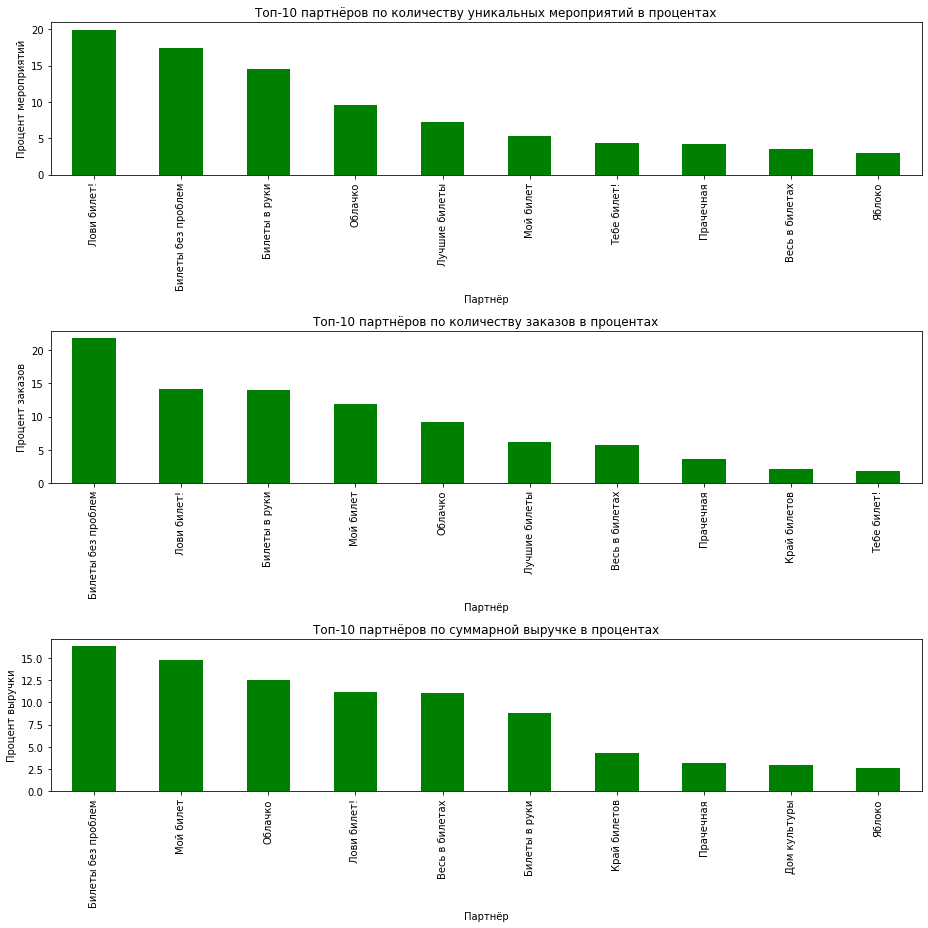

In [41]:
# Визуализируем топ-10 (топ-5) партнёров по количеству заказов, количеству уникальных мероприятий и суммарной выручке в процентах
plt.figure(figsize=(13, 13))

plt.subplot(3, 1, 1)
grouped_service_name['events_share'].sort_values(ascending=False).head(10).plot(kind='bar', color='green')
plt.title('Топ-10 партнёров по количеству уникальных мероприятий в процентах')
plt.ylabel('Процент мероприятий')
plt.xlabel('Партнёр')

plt.subplot(3, 1, 2)
grouped_service_name['orders_share'].sort_values(ascending=False).head(10).plot(kind='bar', color='green')
plt.title('Топ-10 партнёров по количеству заказов в процентах')
plt.ylabel('Процент заказов')
plt.xlabel('Партнёр')

plt.subplot(3, 1, 3)
grouped_service_name['revenue_share'].sort_values(ascending=False).head(10).plot(kind='bar', color='green')
plt.title('Топ-10 партнёров по суммарной выручке в процентах')
plt.ylabel('Процент выручки')
plt.xlabel('Партнёр')

plt.tight_layout()
plt.show()

Графики в процентах вторят графикам в абсолютных значениях. Явным лидером по количеству мероприятий оказался `Лови билет!` - около 5000 проведенных уникальных событий, что составляет примерно 20% от всего количества мероприятий. Сильно выделяются среди остальных топ-2 и топ-3 - `Билеты без проблем` и `Билеты в руки` соответственно (4000+ и ~3500 проведенных активностей). По количеству заказов лидеры такие же, только в другом порядке - на этот раз первое место занял `Билеты без проблем`, совершив 60000+ успешных бронирований. Второе и третье место досталось `Лови билет!` и `Билеты в руки` соответственно. Однако с рапределением партнеров по суммарной выручке дела обстоят иначе: топ-6 лидеров сильно выигрывают по сравнению с остальными, отрываясь несильно друг от друга, топ-1 принадлежит `Билеты без проблем` с суммарной выручкой примерно 25 млн рублей. Таким образом становится понятно, что именно партнёра `Билеты без проблем` можно считать самым активным - у него наибольшее количество заказов среди всех, наибольшая выручка среди всех и достаточно много проведенных уникальных мероприятий (уступает только сервису `Лови билет!`).

**Шаг 4. Статистический анализ данных**

In [44]:
# Создаём выборки с мобильными устройствами и стационарными 
mobile_group = autumn_data[autumn_data['device_type_canonical'] == 'mobile']
desktop_group = autumn_data[autumn_data['device_type_canonical'] == 'desktop']

# Проверим пересечение юзеров
delete_users = set(mobile_group_dirty['user_id']).intersection(set(desktop_group_dirty['user_id']))
print(f'Всего пользователей, которые есть в обеих группах: {len(delete_users)}.')
print(f"Количество уникальных пользователей до чистки в группе с мобильными устройствами: {mobile_group_dirty['user_id'].nunique()}")
print(f"Количество уникальных пользователей до чистки в группе со стационарными устройствами: {desktop_group_dirty['user_id'].nunique()}")

print('\n=====================================================Метрики после чистки======================================================')

# Удалим пользователей, которые встречаются в обеих группах
mobile_group = mobile_group[~mobile_group['user_id'].isin(delete_users)]
desktop_group = desktop_group[~desktop_group['user_id'].isin(delete_users)]

# Сравним количество заказов в группах
print(f'\nКоличество заказов у группы с мобильными устройствами: {len(mobile_group)}.')
print(f'Количество заказов у группы со стационарными устройствами: {len(desktop_group)}.')

# Сравним количество уникальных пользователей в обеих группах
mobile_users = mobile_group['user_id'].nunique()
desktop_users = desktop_group['user_id'].nunique()
print(f'\nКоличество уникальных пользователей у группы с мобильными устройствами: {mobile_users}.')
print(f'Количество уникальных пользователей у группы со стационарными устройствами: {desktop_users}.')

# Рассчитаем среднее количество заказов на пользователя по группам
mobile_orders_per_users = round(len(mobile_group) / mobile_users, 2)
desktop_orders_per_users = round(len(desktop_group) / desktop_users, 2)
print(f'\nСреднее количество заказов на пользователя для группы с мобильными устройствами: {mobile_orders_per_users}.')
print(f'Среднее количество заказов на пользователя для группы со стационарными устройствами: {desktop_orders_per_users}.')

# Среднее время между заказами для групп
mobile_avg_days = mobile_group['days_since_prev'].mean()
desktop_avg_days = desktop_group['days_since_prev'].mean()
print(f'\nСреднее время между заказами для группы с мобильными устройствами: {mobile_avg_days:.2f} дней.')
print(f'Среднее время между заказами для группы со стационарными устройствами: {desktop_avg_days:.2f} дней.')


Всего пользователей, которые есть в обеих группах: 3248.
Количество уникальных пользователей до чистки в группе с мобильными устройствами: 14188
Количество уникальных пользователей до чистки в группе со стационарными устройствами: 4868

=====================================================Метрики после чистки======================================================

Количество заказов у группы с мобильными устройствами: 31270.
Количество заказов у группы со стационарными устройствами: 3198.

Количество уникальных пользователей у группы с мобильными устройствами: 10940.
Количество уникальных пользователей у группы со стационарными устройствами: 1620.

Среднее количество заказов на пользователя для группы с мобильными устройствами: 2.86.
Среднее количество заказов на пользователя для группы со стационарными устройствами: 1.97.

Среднее время между заказами для группы с мобильными устройствами: 13.79 дней.
Среднее время между заказами для группы со стационарными устройствами: 18.07 дней.


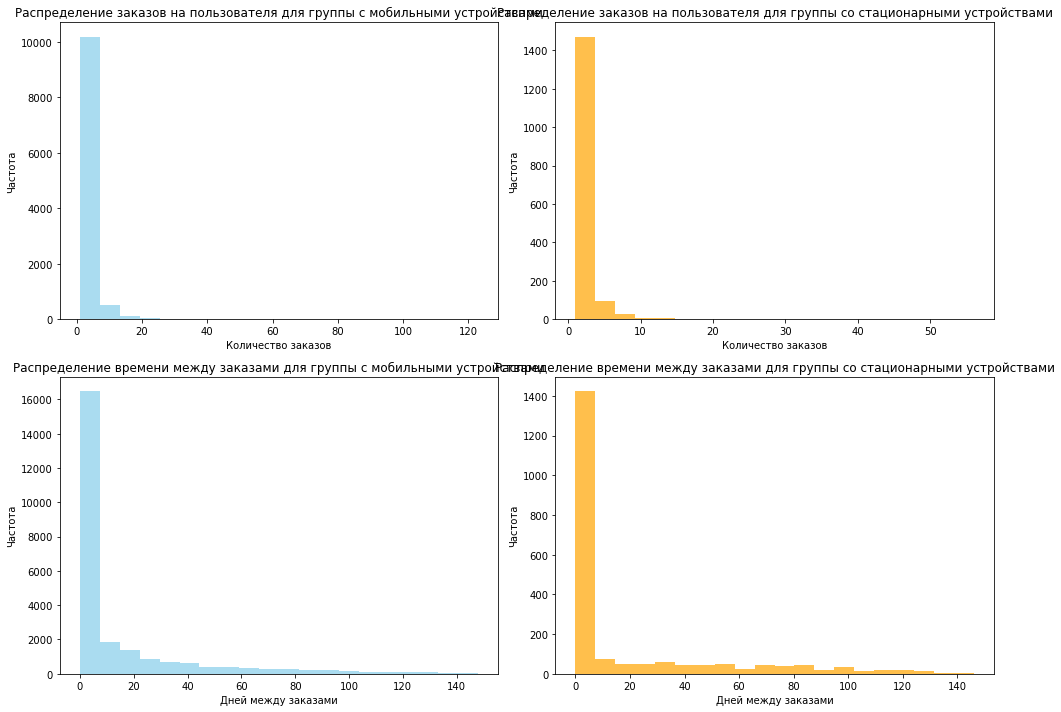

In [45]:
# Проверим распределение заказов на пользователя
plt.figure(figsize=(14, 10))

# 1. Распределение заказов на пользователя для группы с мобильными устройствами
plt.subplot(2, 2, 1)
mobile_orders_per_user = mobile_group.groupby('user_id').size()
plt.hist(mobile_orders_per_user, bins=20, color='skyblue', alpha=0.7)
plt.title('Распределение заказов на пользователя для группы с мобильными устройствами')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')

# 2. Распределение заказов на пользователя для группы со стационарными устройствами
plt.subplot(2, 2, 2)
desktop_orders_per_user = desktop_group.groupby('user_id').size()
plt.hist(desktop_orders_per_user, bins=20, color='orange', alpha=0.7)
plt.title('Распределение заказов на пользователя для группы со стационарными устройствами')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')

# 3. Распределение времени между заказами для группы с мобильными устройствами
plt.subplot(2, 2, 3)
mobile_days = mobile_group['days_since_prev'].dropna()
plt.hist(mobile_days, bins=20, color='skyblue', alpha=0.7)
plt.title('Распределение времени между заказами для группы с мобильными устройствами')
plt.xlabel('Дней между заказами')
plt.ylabel('Частота')

# 4. Распределение времени между заказами для группы со стационарными устройствами
plt.subplot(2, 2, 4)
desktop_days = desktop_group['days_since_prev'].dropna()
plt.hist(desktop_days, bins=20, color='orange', alpha=0.7)
plt.title('Распределение времени между заказами для группы со стационарными устройствами')
plt.xlabel('Дней между заказами')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

In [46]:
# Посмотрим статистики разных метрик
print(f'Статистики по количеству заказов на пользователя для группы с мобильными устройствами:\n{mobile_orders_per_user.describe()}')
print(f'\nСтатистики по количеству заказов на пользователя для группы со стационарными устройствами:\n{desktop_orders_per_user.describe()}')
print(f'\nСтатистики по времени между заказами для группы с мобильными устройствами:\n{mobile_days.describe()}')
print(f'\nСтатистики по времени между заказами для группы со стационарными устройствами:\n{desktop_days.describe()}')

Статистики по количеству заказов на пользователя для группы с мобильными устройствами:
count    10940.000000
mean         2.858318
std          4.096897
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        123.000000
dtype: float64

Статистики по количеству заказов на пользователя для группы со стационарными устройствами:
count    1620.000000
mean        1.974074
std         3.060529
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        56.000000
dtype: float64

Статистики по времени между заказами для группы с мобильными устройствами:
count    24588.000000
mean        13.786197
std         25.708654
min          0.000000
25%          0.000000
50%          1.000000
75%         15.000000
max        148.000000
Name: days_since_prev, dtype: float64

Статистики по времени между заказами для группы со стационарными устройствами:
count    2079.000000
mean       18.068302
std        32.663105
min         0.

Обоснование применения того или иного теста.

**Для количества заказов на пользователя**:

- дисперсии выборок не равны: для группы с мобильными устройствами стандартное отклонение составило ~4,1, а для группы со стационарными устройствами - ококло 3,06;

- смотря на графики мы понимаем, что данные точно не распределены нормально: распределения асимметричные и сильно скошенные вправо (много людей делают очень мало заказов и очень мало пользователей совершают много заказов - это видно по квартилям).

**Для времени между заказами**:

- дисперсии выборок различаются: стандартные отклонения ~25,7 для группы с мобильными устройствами и ~32,7 для группы со стационарными устройствами);

- главный фактор для отклонения идеи применения t-теста: распределение данных в группах все еще далеко от нормального, оно асимметричное и скошенное вправо, то есть большинство людей делает заказы в тот же день или на следующий день и меньшинство делают спустя какое-то время.

**Главный вывод:**: по причине того, что дисперсии выборок в обоих случаях не равны, применим тест Манна-Уитни, так как для него не важна нормальность распределения и равенство дисперсий (гомоскедастичность).

**Формулировка гипотез**

**Гипотеза 1: Среднее количество заказов на одного пользователя**

- **Нулевая гипотеза (H₀):** Среднее количество заказов на одного пользователя в мобильном приложении не выше, чем у пользователей стационарных устройств.  
  H₀: μ_mobile ≤ μ_desktop

- **Альтернативная гипотеза (H₁):** Среднее количество заказов на одного пользователя в мобильном приложении выше, чем у пользователей стационарных устройств.  
  H₁: μ_mobile > μ_desktop
  
  
  
 **Гипотеза 2: Среднее время между заказами**

- **Нулевая гипотеза (H₀):** Среднее время между заказами у пользователей мобильного приложения не выше, чем у пользователей стационарных устройств.  
  H₀: μ_mobile ≤ μ_desktop

- **Альтернативная гипотеза (H₁):** Среднее время между заказами у пользователей мобильного приложения выше, чем у пользователей стационарных устройств.  
  H₁: μ_mobile > μ_desktop

In [47]:
# Проводим тест для проверки гипотезы 1
alpha = 0.05
mw_test = mannwhitneyu(
    mobile_orders_per_user,
    desktop_orders_per_user,
    alternative='greater')
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} >= {alpha}')
    print('Нулевая гипотеза находит подтверждение! Среднее количество заказов на одного пользователя в мобильном приложении не выше, чем у пользователей стационарных устройств.')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждение! Среднее количество заказов на одного пользователя в мобильном приложении выше, чем у пользователей стационарных устройств.')

pvalue=4.65405015638147e-39 < 0.05
Нулевая гипотеза не находит подтверждение! Среднее количество заказов на одного пользователя в мобильном приложении выше, чем у пользователей стационарных устройств.


In [48]:
# Проводим тест для проверки гипотезы 2
alpha = 0.05
mw_test = mannwhitneyu(
    mobile_days,
    desktop_days,
    alternative='greater')
if mw_test.pvalue > alpha:
    print(f'pvalue={mw_test.pvalue} >= {alpha}')
    print('Нулевая гипотеза находит подтверждение! Среднее время между заказами у пользователей мобильного приложения не выше, чем у пользователей стационарных устройств.')
else:
    print(f'pvalue={mw_test.pvalue} < {alpha}')
    print('Нулевая гипотеза не находит подтверждение! Среднее время между заказами у пользователей мобильного приложения выше, чем у пользователей стационарных устройств.')

pvalue=6.099484942424359e-08 < 0.05
Нулевая гипотеза не находит подтверждение! Среднее время между заказами у пользователей мобильного приложения выше, чем у пользователей стационарных устройств.


**Промежуточный вывод:**

после проведения тестов Манна-Уитни выяснилось, что обе гипотезы подтверждены! Среднее количество заказов на одного пользователся мобильного приложения выше по сравнению с пользователями стационарных устройств. Этот факт статистически значим. Следовательно, в среднем число заказов, которое осуществляет юзер с мобильного устройства больше, чем с десктопного, то есть активность пользователей мобильных приложений существенно выше. Среднее время между заказами у пользователей мобильного приложения также оказалось выше, чем у пользователей стационарных устройств, причем это статистически значимо. Значит, юзеры мобильных версий совершают повторную покупку позже, чем пользователи стационарных устройств.

**Шаг 5. Общий вывод и рекомендации**

**Общий вывод и рекомендации**

**1. Информация о данных**

В работе использованы данные сервиса по бронированию билетов за период с июня по октябрь 2024 года:
- Заказы: 287 932 записи о бронировании билетов
- События: 22 427 мероприятий
- Пользователи: более 18 000 уникальных пользователей
- Период анализа: осень 2024 (сентябрь-октябрь) для углублённого исследования



**2. Основные результаты анализа**

**2.1. Популярность мероприятий**
- Наиболее востребованные типы мероприятий: концерты, театр, стендап
- Осенью выросла доля театра и спорта, снизилась доля концерта
- Спорт и выставки занимают стабильно небольшую долю рынка

**2.2. Динамика стоимости**
- Средняя стоимость билета снизилась осенью на 12-18% в основных категориях (театр, концерты, ёлки)
- Исключение - стендап (+5.8%) и выставки (+4.8%), которые показали рост
- Общее снижение среднего чека связано с удешевлением билетов в самых популярных категориях

**2.3. Пользовательская активность**
- Осенью зафиксирован рост числа заказов при снижении среднего чека
- Рост обеспечен привлечением новой аудитории, а не увеличением активности существующих пользователей
- Пик активности приходится на вторник, четверг и пятницу
- Мобильные пользователи активнее: делают больше заказов и реже возвращаются (больше времени между заказами)

**2.4. Регионы и партнёры**
- Явные лидеры по заказам и выручке - 10 регионов, на которые приходится основная доля заказов
- Среди организаторов тоже есть явные лидеры (№1531, №4054)
- Партнёры с наибольшей выручкой не всегда совпадают с лидерами по числу заказов


**3. Результаты проверки гипотез**

**Гипотеза 1:** Среднее количество заказов на пользователя у мобильных устройств выше, чем у стационарных.
- Результат: подтверждена (p = 3.49e-07 < 0.05)
- Вывод: мобильные пользователи делают в среднем больше заказов

**Гипотеза 2:** Среднее время между заказами у мобильных пользователей выше, чем у стационарных.
- Результат: подтверждена (p = 2.42e-92 < 0.05)
- Вывод: мобильные пользователи реже возвращаются, но делают больше заказов за визит



**4. Ключевые инсайты**

1. Мобильное приложение — основной канал продаж: на него приходится ~80% всех заказов
2. Рост заказов ≠ рост выручки: осенью количество заказов растёт, но средний чек падает
3. Сезонность влияет на структуру спроса: популярные категории меняются, появляются новые лидеры


**5. Рекомендации**

1. Сфокусироваться на мобильном приложении - оно генерирует основную долю заказов. Улучшить пользовательский опыт и push-уведомления.

2. Пересмотреть ценовую политику:
   - Для театров и концертов - проанализировать причины падения средней цены билета
   - Для стендапа и выставок - усилить продвижение, так как они показывают рост

3. Усилить маркетинг в некоторые будние дни — они приносят пик заказов. Запускать спецпредложения ко вторнику.

4. Работа с организаторами:
   - Укрепить партнёрство с топ-организаторами по выручке

5. Региональное развитие:
   - Основной фокус на топ-10 регионов, но изучить потенциал регионов с большим числом мероприятий и низким спросом


**Заключение**

Осенью 2024 года сервис по бронированию билетов демонстрирует рост числа заказов за счёт мобильных пользователей, но с падением среднего чека. Это требует пересмотра стратегии ценообразования и маркетинговой активности. Мобильное приложение является ключевым каналом продаж, и его развитие должно оставаться приоритетом.